<a href="https://colab.research.google.com/github/Squirrelcoding/ISLP/blob/main/Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
from statsmodels.stats.outliers_influence \
  import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [ ]:
%pip install ISLP

In [ ]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [ ]:
A = np.array([3, 5, 11])
A.sum()

19

In [ ]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [ ]:
X = pd.DataFrame({
    "intercept": np.ones(Boston.shape[0]),
    "lstat": Boston['lstat']
})

X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [ ]:
y = Boston['medv']
model = sm.OLS(y, X)
results = model.fit()

In [ ]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


In [ ]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)

X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [ ]:
results.params

,0
intercept,34.553841
lstat,-0.950049


In [ ]:
new_df = pd.DataFrame({"lstat": [5, 10, 15]})
newX = design.transform(new_df)

newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [ ]:
new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [ ]:
new_predictions.conf_int(alpha=0.05, obs=True)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

In [ ]:
def abline(ax, b, m, *args, **kwargs):
  "Add a line with slope `m` and intercept `b` to `ax`"
  xlim = ax.get_xlim()
  ylim = [m * xlim[0] + b, m * xlim[1] + b]
  ax.plot(xlim, ylim, *args, **kwargs)

/tmp/ipython-input-17-199927131.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)


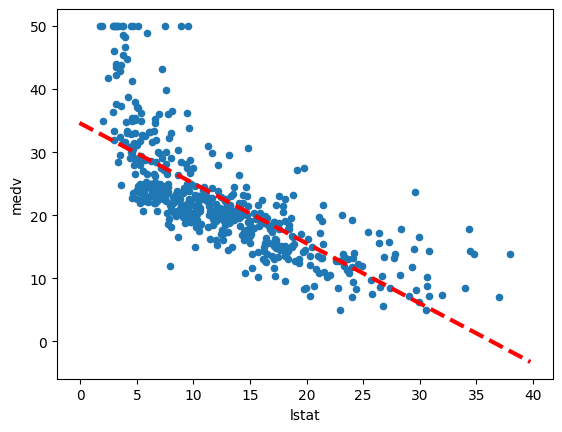

In [ ]:
ax = Boston.plot.scatter("lstat", "medv")

abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)

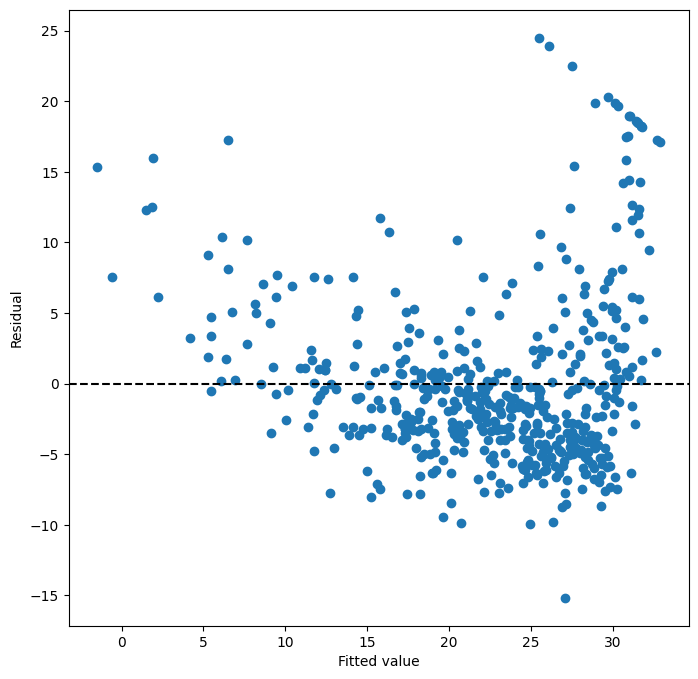

In [ ]:
ax = plt.subplots(figsize=(8, 8))[1]

ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel("Fitted value")
ax.set_ylabel("Residual")
ax.axhline(0, c='k', ls='--')

374

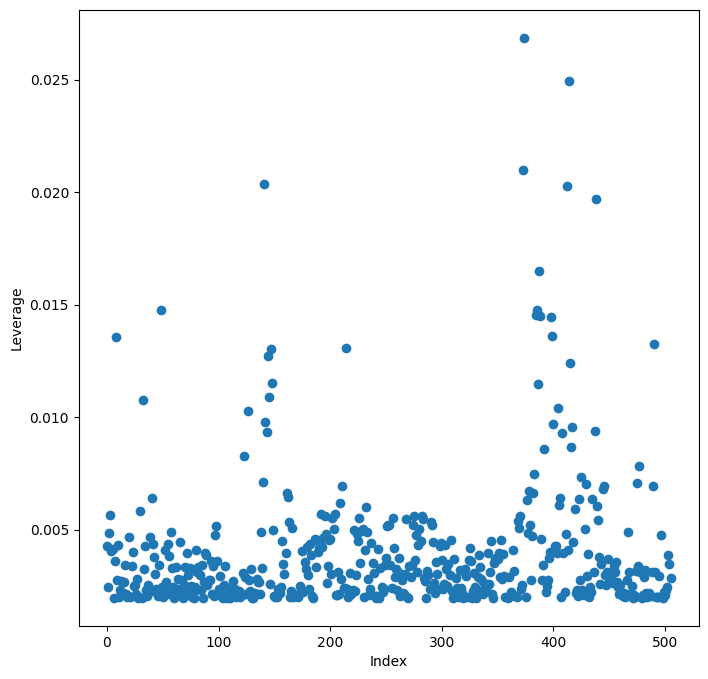

In [ ]:
infl = results.get_influence()
ax = plt.subplots(figsize=(8, 8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [ ]:
X = MS(['lstat', 'age']).fit_transform(Boston)
model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [ ]:
terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

In [ ]:
X = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In [ ]:
minus_age = Boston.columns.drop(['medv', 'age'])
Xma = MS(minus_age).fit_transform(Boston)
model1 = sm.OLS(y, Xma)
summarize(model1.fit())

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


In [ ]:
np.sqrt(results.scale)

4.798034335596367

In [ ]:
vals = [VIF(X, i) for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif': vals}, index=X.columns[1:])

vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


In [ ]:
X = MS(['lstat', 'age', ('lstat', 'age')]).fit_transform(Boston)
model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


In [ ]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [ ]:
X = MS([poly('lstat', degree=2, raw=True), 'age']).fit_transform(Boston)
model30 = sm.OLS(y, X)
results30 = model30.fit()
summarize(results30)

,coef,std err,t,P>|t|
intercept,41.2885,0.873,47.284,0.0
"poly(lstat, degree=2, raw=True)[0]",-2.6883,0.131,-20.502,0.0
"poly(lstat, degree=2, raw=True)[1]",0.0495,0.004,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [ ]:
anova_lm(results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


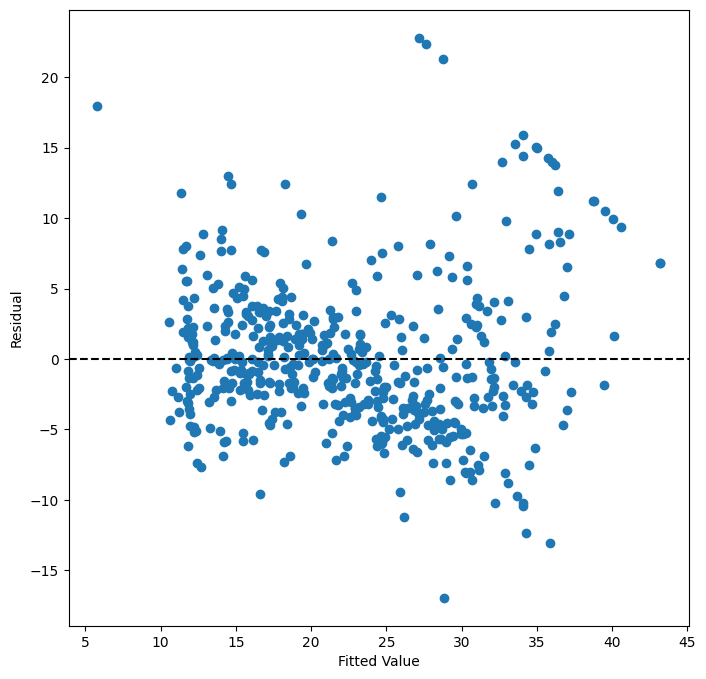

In [ ]:
ax = plt.subplots(figsize=(8, 8))[1]

ax.scatter(results3.fittedvalues, results3.resid)
ax.set_xlabel('Fitted Value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

In [ ]:
Carseats = load_data('Carseats')
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [ ]:
allvars = list(Carseats.columns.drop('Sales'))
y = Carseats['Sales']

final = allvars + [('Income', 'Advertising'), ('Price', 'Age')]

X = MS(final).fit_transform(Carseats)
model = sm.OLS(y, X)
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288


# Conceptual Exercises

## Exercise 1

The $p$-values in Table 3.4 correspond to the null hypothesis that all of the respective coefficients are zero. If $\beta_i$ is the coefficient for the $i$th predictor, then the corresponding $p$-value is the probability that we observed the estimated coefficient based on the data, assuming that the true coefficient is zero. Therefore,

- The coefficient for `Intercept` is 2.939 and its $p$-value is less than $0.0001$. This means that if the actual coefficient is indeed zero (that is, there is no relationship), then the probability that we observed 2.939 is extremely unlikely that it's essentially impossible, so we end up rejecting the null hypothesis and conclude that it is indeed the value $2.939$. Similar reasoning can be applied to the coefficients for `TV` and `radio`.

- The $p$-value for `newspaper` is 0.8599, which is significant. It means that if the true coefficient for `newspaper` really is zero, then the probability that we observed -0.001 is very likely. This does not provide any evidence for rejecting the null hypothesis, so we "stay" with it and conclude that there is no significant relationship.

The conclusion is that `TV` and `radio` are the only two significant predictors, while `newspaper` is not significant. If we do not allocate any sales, then we will only sell around 2,939 units.

## Exercise 2


The KNN classifier is used for classification problems. Suppose that we are given an integer $K$ and a collection of observations and asked to classify a new example $x_0$. The KNN classifier attempts to estimate the Bayes classifier by assigning $x_0$ to the class $j$ for which $P(Y = j \mid X = x_0)$ is highest.

This is in contrast to the KNN regression method. Suppose we are given a set of points (which account for the predictors and response variables) and asked to predict the value of a particular point $x_0$. Similar to KNN classification, the KNN regression method takes the average of the response variables of the nearest $K$ points in terms of predictors.

Although the methods appear to be similar, there are several key differences to account for.

1. It is straightforward to see that KNN classification is for classification and KNN regression is for regression problems.

2. KNN classification uses the mode (most common) of the nearest $K$ neighbors as its prediction, while KNN regression uses the average of the nearest $K$ neighbors.

3. KNN classification performs poorly for large $K$ and better for smaller $K$. In particular, it has lower error rates for lower $K$. This is because a large $K$ results in an almost-linear boundary line with high bias and low variance. On the other hand, KNN regression perfroms well for larger $K$ and far worse when $K$ is small in terms of MSE, since a larger $K$ increases variance which is preferred for regression.

## Exercise 3

- (a) Let us rewrite the equation for the case where $x_3 = 1$ and the case where $x_3 = 0$. We obtain:

$$
 \begin{array}{cl}
y = 85 + 10x_1 + 0.07x_2 + 0.01x_1x_2 & \ x_3 = 1 \\
y = 50 + 20x_1 + 0.07x_2 + 0.01x_1x_2  &\ x_3 = 0
\end{array}
$$

Where the first equation represents the expected earnings for a college graduate while the second represents the expected earnings for a high school graduate. Let us assume that $x_1$ and $x_2$ are equal in both equations. Subtracting $0.07x_2 + 0.01x_1 x_2$ (this part has no effect on whether one is greater than the other) we are left with $85 + 10x_1$ and $50 + 20x_1$.

Surprisingly, if $x_1 \geq 3.5$ then we see that $50 + 20x_1 \geq 85 + 10x_1$. In other words, if the GPA is at least 3.5, then the high school graduate can expect to earn more than their college counterpart. Thus, (iii) is correct.

- (b) We let $x_1 = 4$ and $x_2 = 110$. Using the formula above, we see that $y \approx 137.1$. Thus, a college graduate with a 4.0 GPA and an IQ of 110 can expect to earn a salary of $137,100.

- (c) False. The $p$-value and/or the data would provide evidence for or against the null hypothesis that there is no relationship. We may not draw conclusions from the coefficient itself.

## Exercise 4

- (a) The cubic model introduces more variance and reduces the bias. Since it is more flexible, it will have a lower training RSS.
- (b) Although the cubic model is more flexible, it is also more prone to overfitting. Since the data is "simple," a model with high bias and low variance is preferred. Here, the linear model's test RSS should be expected to be lower.

- (c) Once again the flexibility of the cubic model allows it to have a lower training RSS than the linear model, even in the case that the data has a linear relationship. Thus it will have a lower training RSS.

- (d) There is not enough information to tell. If the data does follow an almost-linear trend, then from (b) we know that the linear model will have a test RSS. But if the data is nonlinear, say cubic, then the cubic model will clearly have a lower test RSS.

## Exercise 5

It is easily shown that $a_{i'} = \frac{x_i x_{i'}}{ \sum_{j = 1}^n x_j^2 }$

## Exercise 6

It suffices to show that $\bar y = \hat\beta_0 + \hat\beta_1 \bar x$. Indeed, from equation 3.4 we know that $\hat\beta_0 = \bar y - \hat\beta_1 \bar x$ so $\hat\beta_1 \bar x + (\bar y - \hat\beta_1 \bar x) = \bar y$.

Not gonna do the last one it

## Exercise 8

In [ ]:
Auto = load_data("Auto")

X = MS(['horsepower']).fit_transform(Auto)
y = Auto['mpg']

model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Wed, 02 Jul 2025   Prob (F-statistic):           7.03e-81
Time:                        23:50:35   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
X = pd.DataFrame({'lstat': [95]})

prediction = results.get_prediction(design.transform(X))

print(prediction.predicted_mean)

print(prediction.conf_int(alpha=0.05))
print(prediction.conf_int(obs=True, alpha=0.05))

[24.94061135]
[[24.4389014 25.4423213]]
[[15.28253274 34.59868997]]


- (a)
  - i. The $p$-value of the coefficient of `horsepower` is extremely small. Since it is nonzero, this strongly suggests that there is indeed a relationship between `horsepower` and `mpg`.
  - ii. The $R^2$ measure of the model is about 0.61. This means that about 61% of the variance in the data is explained by the model.
  - iii. The sign of the coefficient is negative, so there is a negative relationship between horsepower and mpg.
  - iv. With a horsepower of 95%, the 95% confidence interval for the predicted MPG is [24.4389014 25.4423213] with a mean of about 24.94. The 95% prediction interval for the MPG at 95% horsepower is [15.28253274 34.59868997].

/tmp/ipython-input-35-832506865.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], c='k')


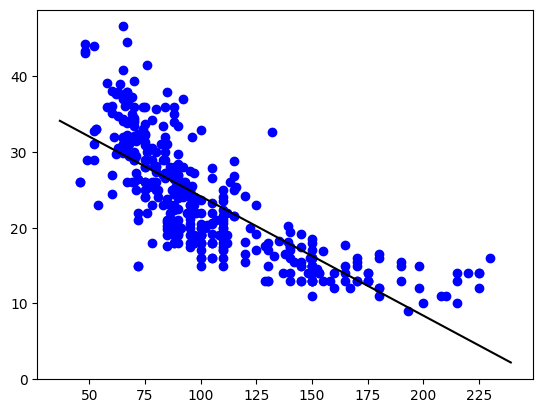

In [ ]:
fig, ax = plt.subplots()

ax.scatter(Auto['horsepower'], Auto['mpg'], c='b')

abline(ax, results.params[0], results.params[1], c='k')

Now we plot the residuals

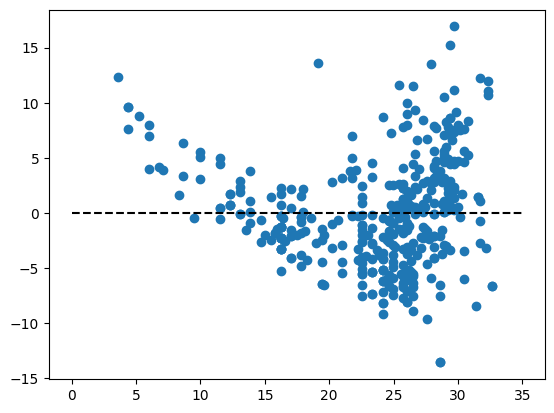

In [ ]:
fig, ax = plt.subplots()

ax.hlines(0, 0, 35, colors=['k'], linestyles=['--'])
ax.scatter(results.fittedvalues, results.resid)

115

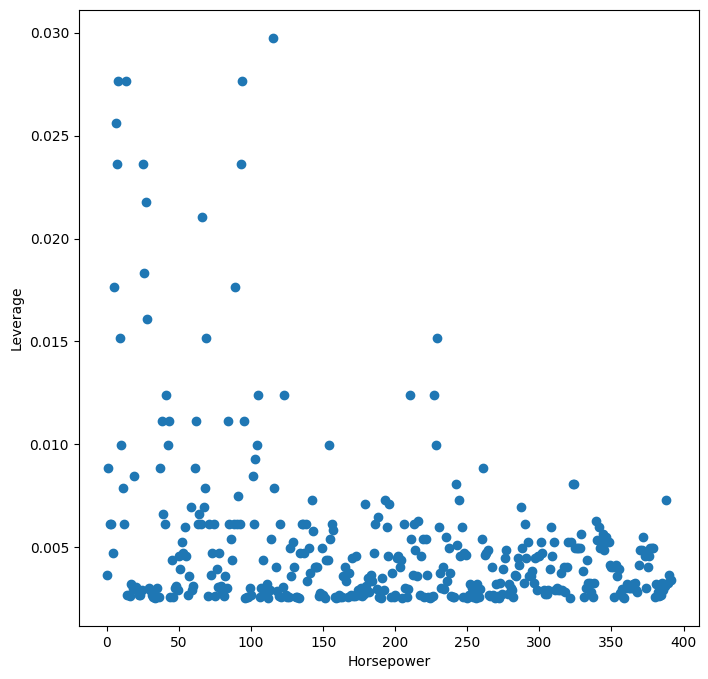

In [ ]:
design = MS(['mpg'])
X = design.fit_transform(Auto)

infl = results.get_influence()

ax = plt.subplots(figsize =(8 ,8))[1]

ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Horsepower')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

The average leverage is $(p+1) / n$ where $p=1$ and $n=392$. There are many points whose leverage is about six times the average. Furthermore, the scatter and residual plots strongly suggest that the relationship may not be linear.

## Exercise 9

- (a)

array([[<Axes: xlabel='mpg', ylabel='mpg'>,
        <Axes: xlabel='cylinders', ylabel='mpg'>,
        <Axes: xlabel='displacement', ylabel='mpg'>,
        <Axes: xlabel='horsepower', ylabel='mpg'>,
        <Axes: xlabel='weight', ylabel='mpg'>,
        <Axes: xlabel='acceleration', ylabel='mpg'>,
        <Axes: xlabel='year', ylabel='mpg'>,
        <Axes: xlabel='origin', ylabel='mpg'>],
       [<Axes: xlabel='mpg', ylabel='cylinders'>,
        <Axes: xlabel='cylinders', ylabel='cylinders'>,
        <Axes: xlabel='displacement', ylabel='cylinders'>,
        <Axes: xlabel='horsepower', ylabel='cylinders'>,
        <Axes: xlabel='weight', ylabel='cylinders'>,
        <Axes: xlabel='acceleration', ylabel='cylinders'>,
        <Axes: xlabel='year', ylabel='cylinders'>,
        <Axes: xlabel='origin', ylabel='cylinders'>],
       [<Axes: xlabel='mpg', ylabel='displacement'>,
        <Axes: xlabel='cylinders', ylabel='displacement'>,
        <Axes: xlabel='displacement', ylabel='displacement

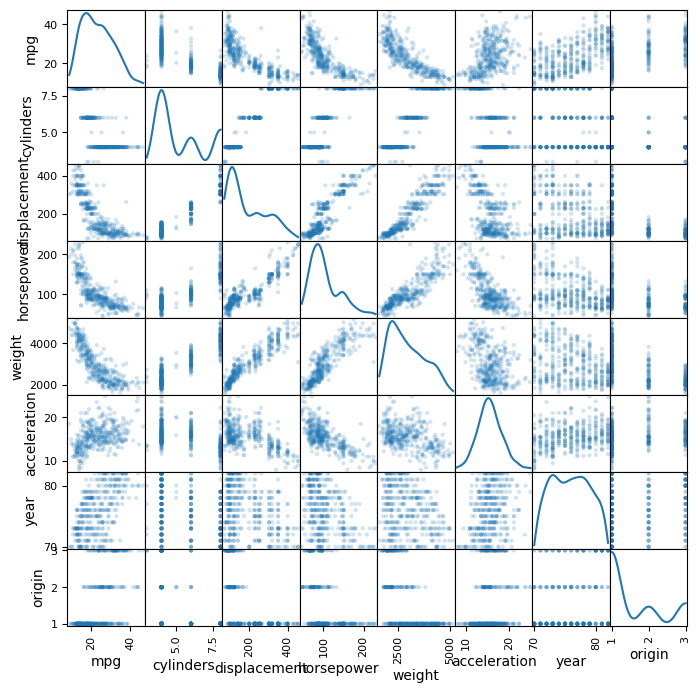

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(Auto, alpha=0.2, diagonal="kde", figsize=(8,8))

In [ ]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [ ]:
Auto = load_data("Auto")
Auto = Auto.reset_index()
y = Auto['mpg']
predictors = Auto.drop(['name', 'mpg'], axis=1).columns
X = MS(predictors).fit_transform(Auto)
model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Thu, 03 Jul 2025   Prob (F-statistic):          2.04e-139
Time:                        00:16:41   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- (i, ii) The displacement, weight, year, and origin all have a significant relationship with the MPG. However, the $p$-values of the number of cylinders, the horsepower, and the acceleration are large enough to suggest that there is no significant relationship between these predictors and the response variables. There is a negative relationship between the weight and a positive relationship between the response and the displacement, year, and origin.
- (iii) When all variables are held fixed and we vary the year, an increase in one year will result in an increase of about 0.75 in the MPG. Hence, more recent makes are more efficient.

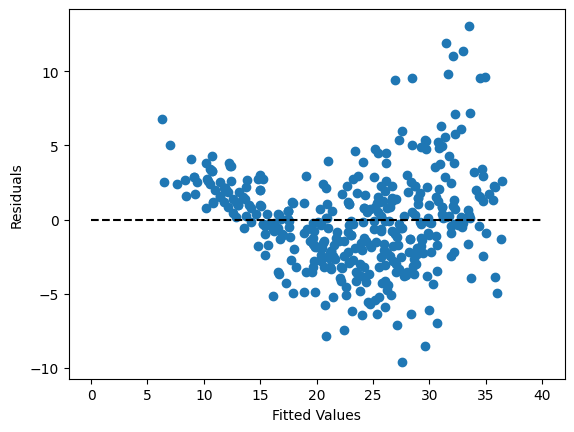

In [ ]:
fig, ax = plt.subplots()

ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.hlines(0, 0, 40, colors=['k'], linestyles=['--'])


In [ ]:
results.fittedvalues

,0
0,15.000959
1,13.999299
2,15.240447
3,15.061906
4,14.967178
...,...
387,28.319554
388,34.464572
389,31.136326
390,29.350244


13

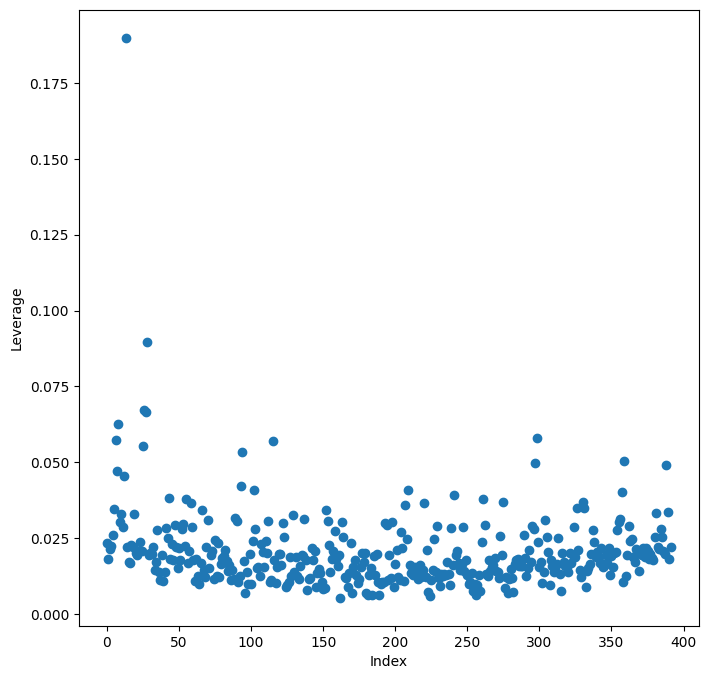

In [ ]:
design = MS(['mpg'])
X = design.fit_transform(Auto)

infl = results.get_influence()

ax = plt.subplots(figsize =(8 ,8))[1]

ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)


In [ ]:
infl.cooks_distance[0].max()

0.07780083513972696

There are no extreme outliers noticable in the residual plot. However, the car at index 13 of `Auto` has extremely high leverage relative to all other examples in the dataset, with a leverage of about 0.19, while the average is about 0.02. The data does not appear to be linear due to the trend of the data in the  residual plot.

To determine what

In [ ]:
y = Auto['mpg']
predictors = list(Auto.drop(['name', 'mpg'], axis=1).columns)
X = MS(predictors + [('weight', 'year')]).fit_transform(Auto)
model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     265.1
Date:                Thu, 03 Jul 2025   Prob (F-statistic):          5.11e-151
Time:                        00:07:32   Log-Likelihood:                -993.17
No. Observations:                 392   AIC:                             2004.
Df Residuals:                     383   BIC:                             2040.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept     -118.5635     13.376     -8.864      0.000    -144.864     -92.263
cylinders       -0.1218      0.303     -0.402      0.688      -0.718       0.474
displacement     0.0129      0.007      1.842      0.066      -0.001       0.027
horsepower      -0.0288      0.013     -2.236      0.026      -0.054      -0.003
weight           0.0304      0.005      6.543      0.000       0.021       0.040
acceleration     0.1447      0.092      1.574      0.116      -0.036       0.326
year             2.0841      0.173     12.033      0.000       1.744       2.425
origin           1.1736      0.260      4.519      0.000       0.663       1.684
weight:year     -0.0005    6.1e-05     -8.002      0.000      -0.001      -0.000
==============================================================================
Omnibus:                       29.856   Durbin-Watson:                   1.426
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               46.946
Skew:                           0.519   Prob(JB):                     6.40e-11
Kurtosis:                       4.340   Cond. No.                     2.00e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large,  2e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

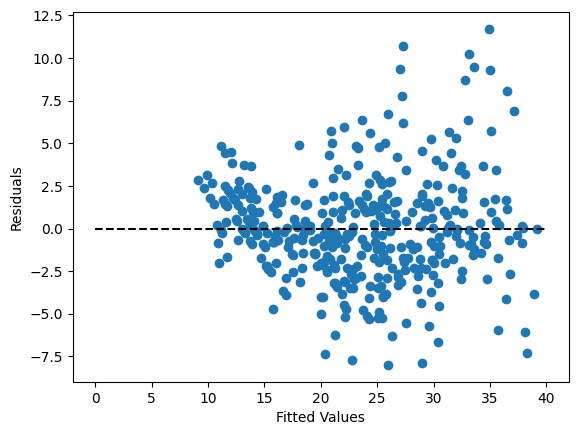

In [ ]:
fig, ax = plt.subplots()

ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.hlines(0, 0, 40, colors=['k'], linestyles=['--'])


In [ ]:
# Miles per gallon, # of cylinders, displacement, horsepower, weight, acceleartion, year, origin

In [ ]:
y = Auto['mpg']
predictors = list(Auto.drop(['name', 'mpg'], axis=1).columns)
X = MS(predictors + [('displacement', 'cylinders')]).fit_transform(Auto)
model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     264.1
Date:                Thu, 03 Jul 2025   Prob (F-statistic):          9.73e-151
Time:                        00:09:50   Log-Likelihood:                -993.83
No. Observations:                 392   AIC:                             2006.
Df Residuals:                     383   BIC:                             2041.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                 -2.7097      4.686     -0.578      0.563     -11.923       6.504
cylinders                 -2.6962      0.409     -6.584      0.000      -3.501      -1.891
displacement              -0.0775      0.014     -5.474      0.000      -0.105      -0.050
horsepower                -0.0476      0.013     -3.559      0.000      -0.074      -0.021
weight                    -0.0052      0.001     -8.370      0.000      -0.006      -0.004
acceleration               0.0598      0.092      0.651      0.515      -0.121       0.240
year                       0.7595      0.047     16.044      0.000       0.666       0.853
origin                     0.7087      0.274      2.590      0.010       0.171       1.247
displacement:cylinders     0.0136      0.002      7.907      0.000       0.010       0.017
==============================================================================
Omnibus:                       35.211   Durbin-Watson:                   1.456
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               88.581
Skew:                           0.432   Prob(JB):                     5.82e-20
Kurtosis:                       5.162   Cond. No.                     1.03e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.03e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

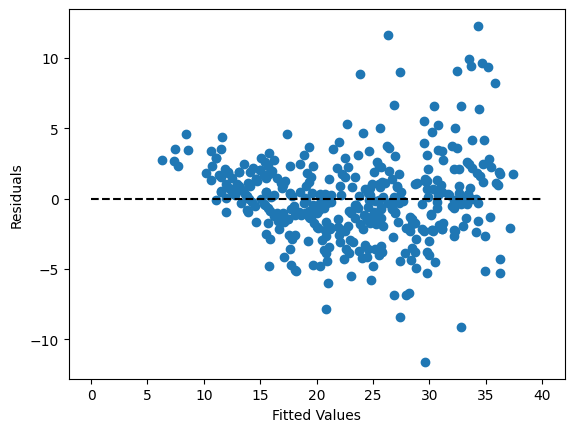

In [ ]:
fig, ax = plt.subplots()

ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.hlines(0, 0, 40, colors=['k'], linestyles=['--'])

There is strong evidence (low $p$-values) for interaction effects between the weight and the year, and between the displacement and the cylinders.

In [ ]:
Auto = load_data("Auto")
Auto = Auto.reset_index()

Auto['weight'] = np.log(Auto['weight'])

y = Auto['mpg']
predictors = list(Auto.drop(['name', 'mpg'], axis=1).columns)
X = MS(predictors + [('displacement', 'cylinders')]).fit_transform(Auto)
model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     280.9
Date:                Thu, 03 Jul 2025   Prob (F-statistic):          4.25e-155
Time:                        00:17:24   Log-Likelihood:                -983.53
No. Observations:                 392   AIC:                             1985.
Df Residuals:                     383   BIC:                             2021.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                114.7864     11.881      9.662      0.000      91.427     138.146
cylinders                 -1.8784      0.423     -4.436      0.000      -2.711      -1.046
displacement              -0.0433      0.015     -2.856      0.005      -0.073      -0.013
horsepower                -0.0350      0.013     -2.629      0.009      -0.061      -0.009
weight                   -17.7632      1.827     -9.721      0.000     -21.356     -14.171
acceleration               0.0810      0.088      0.919      0.359      -0.092       0.254
year                       0.7817      0.046     16.863      0.000       0.691       0.873
origin                     0.6478      0.267      2.429      0.016       0.123       1.172
displacement:cylinders     0.0087      0.002      4.715      0.000       0.005       0.012
==============================================================================
Omnibus:                       44.001   Durbin-Watson:                   1.450
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              105.439
Skew:                           0.569   Prob(JB):                     1.27e-23
Kurtosis:                       5.272   Cond. No.                     1.27e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.27e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Taking the logaritm of the weight slightly increases the $R^2$ value and the $p$-values of the variables.

In [ ]:
Auto = load_data("Auto")
Auto = Auto.reset_index()

Auto['weight'] = np.log(Auto['weight'])
Auto['displacement'] = np.sqrt(Auto['displacement'])
Auto['cylinders'] = np.power(Auto['cylinders'], 6)

y = Auto['mpg']
predictors = list(Auto.drop(['name', 'mpg'], axis=1).columns)
X = MS(predictors + [('displacement', 'cylinders')]).fit_transform(Auto)
model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     290.5
Date:                Thu, 03 Jul 2025   Prob (F-statistic):          1.77e-157
Time:                        00:25:43   Log-Likelihood:                -977.90
No. Observations:                 392   AIC:                             1974.
Df Residuals:                     383   BIC:                             2010.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                101.0182     12.193      8.285      0.000      77.044     124.992
cylinders                 -0.0001   1.82e-05     -5.523      0.000      -0.000   -6.47e-05
displacement              -0.2565      0.175     -1.462      0.145      -0.601       0.088
horsepower                -0.0437      0.013     -3.269      0.001      -0.070      -0.017
weight                   -16.4586      1.887     -8.723      0.000     -20.168     -12.749
acceleration               0.0572      0.088      0.652      0.515      -0.115       0.230
year                       0.7726      0.046     16.916      0.000       0.683       0.862
origin                     0.5950      0.263      2.263      0.024       0.078       1.112
displacement:cylinders  6.256e-06   1.03e-06      6.077      0.000    4.23e-06    8.28e-06
==============================================================================
Omnibus:                       47.561   Durbin-Watson:                   1.450
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              105.236
Skew:                           0.642   Prob(JB):                     1.41e-23
Kurtosis:                       5.190   Cond. No.                     2.07e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.07e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

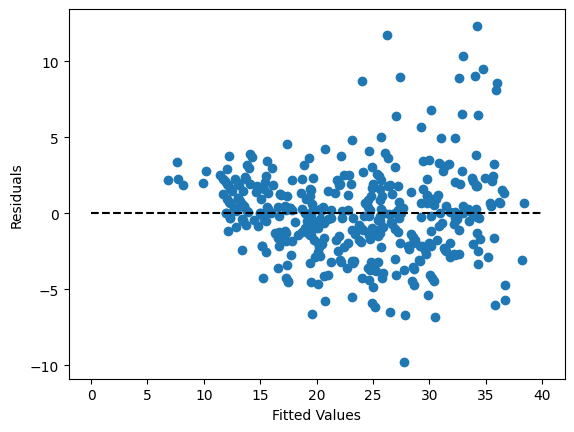

In [ ]:
fig, ax = plt.subplots()

ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.hlines(0, 0, 40, colors=['k'], linestyles=['--'])

After applyig a logarithmic transform on the weight, taking the square root of the displacement, and raising the cylinders to the sixth power we have a slightly better model.

## Exercise 10

In [ ]:
Carseats = load_data("Carseats")

In [ ]:
y = Carseats['Sales']
X = MS(['Price', 'Urban', 'US']).fit_transform(Carseats)
model = sm.OLS(y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Thu, 03 Jul 2025   Prob (F-statistic):           2.39e-23
Time:                        00:32:56   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0435      0.651     20.036      0.000      11.764      14.323
Price         -0.0545      0.005    -10.389      0.000      -0.065      -0.044
Urban[Yes]    -0.0219      0.272     -0.081      0.936      -0.556       0.512
US[Yes]        1.2006      0.259      4.635      0.000       0.691       1.710
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.758
Skew:                           0.093   Prob(JB):                        0.684
Kurtosis:                       2.897   Cond. No.                         628.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- (b)
  - The intercept is about 13.04 with a very small $p$-value, suggesting statistical significance. In particular, this means that in a rural area outside the US, if the car seats were free they would sell about about 13,000 car seats.
  - The coefficient of `price` is about `-0.05` with a small $p$-value. This means that if a car seat is more expensive, the company will sell less units (54.5 less units for every unit increase in price).
  - The coefficent of `urban` is `-0.0219` but has a very high $p$-value, suggesting that it is not significant.
  - The coefficient of `US` is about `1.2`. This means that if the price and geography are fixed, then US stores will typically sell about 1200 units more.

- (c) There are 4 of them so I'm not going to do it.
- (d) We can reject the null hypothesis that $\beta_j = 0$ for the `price` and `US` predictors, since their $p$-values are very small. However, we cannot reject the hypothesis for the `Urban` predictor.
- (e)

In [ ]:
y = Carseats['Sales']
X = MS(['Price', 'US']).fit_transform(Carseats)
model = sm.OLS(y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Thu, 03 Jul 2025   Prob (F-statistic):           2.66e-24
Time:                        00:43:40   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0308      0.631     20.652      0.000      11.790      14.271
Price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
US[Yes]        1.1996      0.258      4.641      0.000       0.692       1.708
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

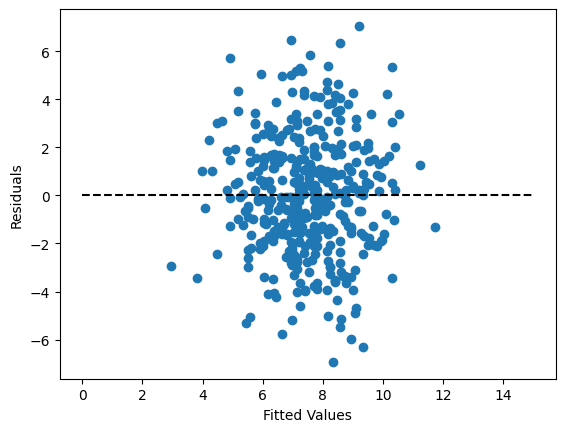

In [ ]:
fig, ax = plt.subplots()

ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.hlines(0, 0, 15, colors=['k'], linestyles=['--'])

- (f) Both models do a poor job of fitting the data, with both having an $R^2$ value of 0.239. However, the second model has a very small improvement in the adjusted $R^2$ statistic with an increase of 0.001.
- (g) Using the results from (a), the 95% confidence interval for the coefficient of `Price` is (-0.0643, -0.0447) and the 95% confidence interval for the coefficient of `US` is (0.69392, 1.70528). For the intercept it's (11.79404, 14.26756).

42

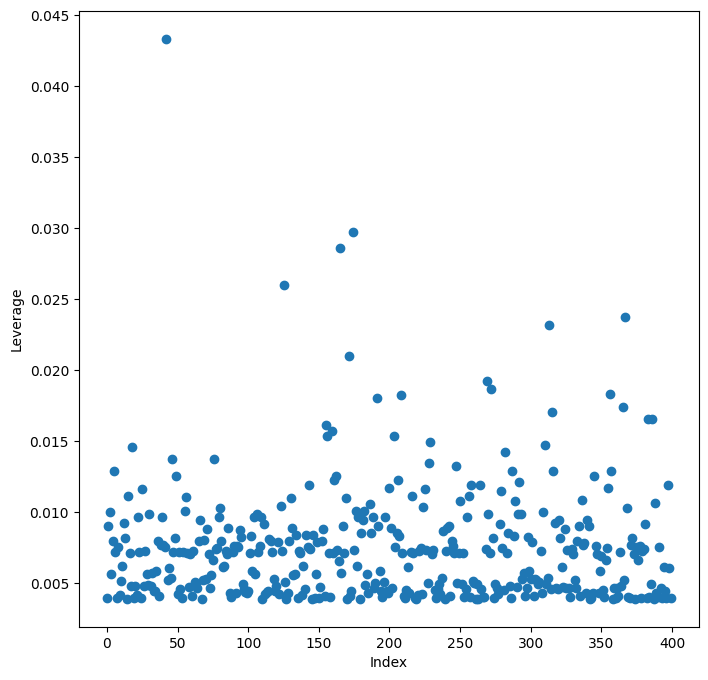

In [ ]:
design = MS(['Sales'])
X = design.fit_transform(Carseats)

infl = results.get_influence()

ax = plt.subplots(figsize =(8 ,8))[1]

ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)


There are a few points with a leverage much higher than the average, but they do not appear to be influential. There do not appear to be any significant outliers.

## Exercise 11

In [ ]:
rng = np.random.default_rng (1)
x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)

In [ ]:
data = pd.DataFrame({'x': x, 'y': y})

In [ ]:
X = MS(['x'], intercept=False).fit_transform(data)
y = data['y']

model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Thu, 03 Jul 2025   Prob (F-statistic):                    6.23e-31
Time:                        01:04:28   Log-Likelihood:                         -141.35
No. Observations:                 100   AIC:                                      284.7
Df Residuals:                      99   BIC:                                      287.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x              1.9762      0.117     16.898      0.000       1.744       2.208
==============================================================================
Omnibus:                        1.376   Durbin-Watson:                   2.184
Prob(Omnibus):                  0.503   Jarque-Bera (JB):                0.847
Skew:                           0.121   Prob(JB):                        0.655
Kurtosis:                       3.381   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The value of $\hat\beta$ is 1.9762 with a standard error of 0.117, a $t$-statistic of 16.898, and a $p$-value of less than 0.0001. This coefficient is a very close estimate of $2$ and even if we did not know that the true coefficient was 2, we may be confident that it is near the true value, since $2$ lies within the 95% confidence interval.

In [ ]:
X = MS(['y'], intercept=False).fit_transform(data)
y = data['x']

model = sm.OLS(y, X)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      x   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Thu, 03 Jul 2025   Prob (F-statistic):                    6.23e-31
Time:                        01:05:00   Log-Likelihood:                         -58.349
No. Observations:                 100   AIC:                                      118.7
Df Residuals:                      99   BIC:                                      121.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
y              0.3757      0.022     16.898      0.000       0.332       0.420
==============================================================================
Omnibus:                       13.156   Durbin-Watson:                   2.034
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               22.596
Skew:                          -0.528   Prob(JB):                     1.24e-05
Kurtosis:                       5.075   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

(b) The coefficient is 0.3757, its standard error is 0.022, its $t$-value is 16.898, and it has a very small $p$-value. This means that we can reject the null hypothesis that $\beta = 0$ and conclude that there is indeed a relationship.

(c) The first coefficient was very close to the true value of $2$, being $1.9762$. The second coefficient was near the true value of $0.5$, with a value of $0.3757$. Notice that the coefficients are not multiplicative inverses of each other. The second estimate is significantly further away from its true value than the first estimate.

(d) skippped.

(e) The $x_i$ and the $y_i$ are symmetrical. That is, they can be switched and make no differnece to the equation. Thus, the $t$-statistic for regression of `y` onto `x` is the same as the $t$-statistic for regression of `x` onto `y`.

## Exercise 12

- (a) They are only equal when $\sum_{i=1}^{n}x_{i}^{2}=\sum_{i=1}^{n}y_{i}^{2}$, where the $x_i$ and the $y_i$ are the observations.
- (b) The example below is that case.

In [ ]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)

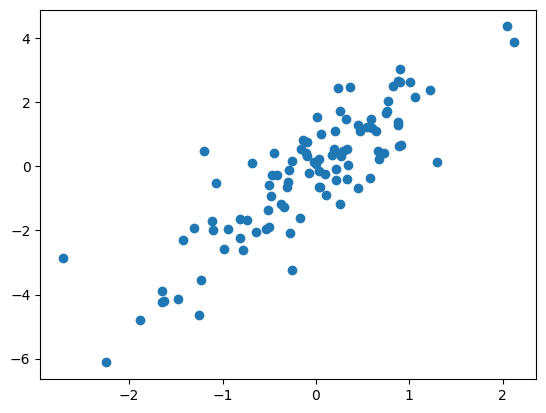

In [ ]:
fig, ax = plt.subplots()

ax.scatter(x, y)

- (c)

In [ ]:
x = rng.normal(size=100)
y = x

data = pd.DataFrame({'x': x, 'y': y})

X = MS(['y'], intercept=False).fit_transform(data)
y = data['x']

model = sm.OLS(y, X)
results = model.fit()

results.summary()

/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:1871: RuntimeWarning: divide by zero encountered in scalar divide
  return self.mse_model/self.mse_resid
/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/stattools.py:50: RuntimeWarning: invalid value encountered in scalar divide
  dw = np.sum(diff_resids**2, axis=axis) / np.sum(resids**2, axis=axis)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      x   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                                inf
Date:                Thu, 03 Jul 2025   Prob (F-statistic):                        0.00
Time:                        01:25:47   Log-Likelihood:                             inf
No. Observations:                 100   AIC:                                       -inf
Df Residuals:                      99   BIC:                                       -inf
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
y              1.0000          0        inf      0.000       1.000       1.000
==============================================================================
Omnibus:                          nan   Durbin-Watson:                     nan
Prob(Omnibus):                    nan   Jarque-Bera (JB):                  nan
Skew:                             nan   Prob(JB):                          nan
Kurtosis:                         nan   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
X = MS(['x'], intercept=False).fit_transform(data)
y = data['y']

model = sm.OLS(y, X)
results = model.fit()

results.summary()

/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:1871: RuntimeWarning: divide by zero encountered in scalar divide
  return self.mse_model/self.mse_resid
/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/stattools.py:50: RuntimeWarning: invalid value encountered in scalar divide
  dw = np.sum(diff_resids**2, axis=axis) / np.sum(resids**2, axis=axis)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                                inf
Date:                Thu, 03 Jul 2025   Prob (F-statistic):                        0.00
Time:                        01:25:51   Log-Likelihood:                             inf
No. Observations:                 100   AIC:                                       -inf
Df Residuals:                      99   BIC:                                       -inf
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x              1.0000          0        inf      0.000       1.000       1.000
==============================================================================
Omnibus:                          nan   Durbin-Watson:                     nan
Prob(Omnibus):                    nan   Jarque-Bera (JB):                  nan
Skew:                             nan   Prob(JB):                          nan
Kurtosis:                         nan   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Exercise 13